# Введение в обучение с учителем
(scikit-learn, numpy, pandas)

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn


Для начала загрузим данные.

In [73]:
data = pd.read_csv('train.csv')
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [74]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [75]:
data = data[["SalePrice", "GrLivArea", "OverallCond", "YearBuilt"]]
data.head()

,SalePrice,GrLivArea,OverallCond,YearBuilt
0,208500,1710,5,2003
1,181500,1262,8,1976
2,223500,1786,5,2001
3,140000,1717,5,1915
4,250000,2198,5,2000


In [76]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

train_target = train_data["SalePrice"]
train_data = train_data.drop(columns=["SalePrice"])
val_target = val_data["SalePrice"]
val_data = val_data.drop(columns=["SalePrice"])

print(train_data.shape, val_data.shape)

(1168, 3) (292, 3)


## Линейная регрессия

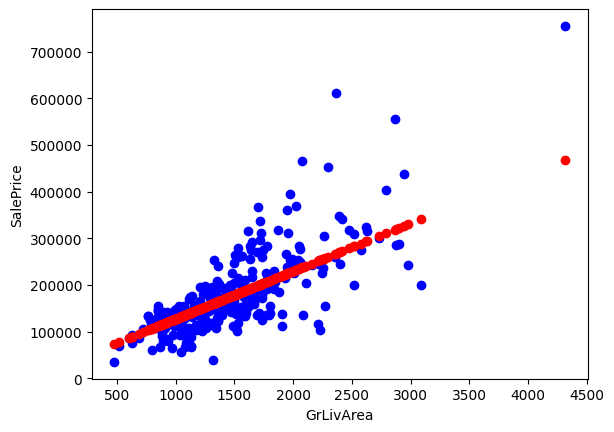

In [85]:
from sklearn.linear_model import LinearRegression
# Создаём модель линейной регрессии
reg = LinearRegression()
# Обучаем модель на тренировочных данных
reg.fit(train_data[["GrLivArea"]], train_target)
# Делаем предсказания на валидационных данных
predicted_prices = reg.predict(val_data[["GrLivArea"]])

# Визуализируем результаты
plt.scatter(val_data["GrLivArea"], val_target, color="blue")
plt.scatter(val_data["GrLivArea"], predicted_prices, color="red")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

Коэффициенты $ax + b$:

In [88]:
print(reg.coef_, reg.intercept_)

[102.48895892] 24899.74815733818


In [89]:
# Считаем лосс
def calculate_loss(reg, train_data, val_data, train_target, val_target):
    train_predicted_prices = reg.predict(train_data)
    train_loss = np.mean((train_predicted_prices - train_target) ** 2)
    val_predicted_prices = reg.predict(val_data)
    val_loss = np.mean((val_predicted_prices - val_target) ** 2)
    return train_loss, val_loss

train_loss, val_loss = \
    calculate_loss(reg, train_data[["GrLivArea"]], val_data[["GrLivArea"]], train_target, val_target)
print(f"Среднеквадратичная ошибка: на train: {train_loss}, на val: {val_loss}")

Среднеквадратичная ошибка: на train: 3078116053.85812, на val: 3418946311.180807


Обучим линейную регрессию на нескольких признаках:

In [116]:
reg = LinearRegression()
reg.fit(train_data, train_target)
predicted_prices = reg.predict(val_data)

# Считаем лосс
train_loss, val_loss = calculate_loss(reg, train_data, val_data, train_target, val_target)
print(f"Среднеквадратичная ошибка: на train: {train_loss}, на val: {val_loss}")

Среднеквадратичная ошибка: на train: 2001858845.0027883, на val: 2375249047.745835


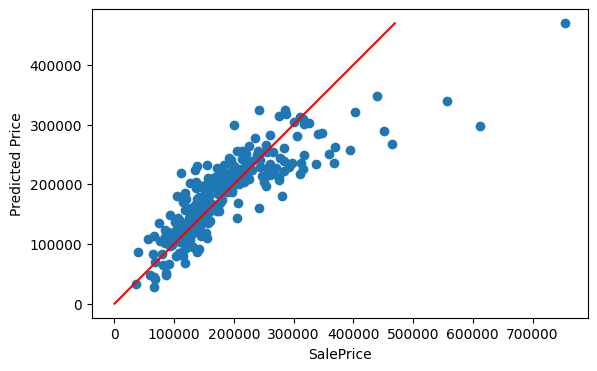

In [118]:
def plot_predicted_prices(predicted_prices, val_target):
    plt.scatter(val_target, predicted_prices)
    plt.plot([0, predicted_prices.max()], [0, predicted_prices.max()], color="red")
    plt.axis("scaled")
    plt.xlabel("SalePrice")
    plt.ylabel("Predicted Price")

plot_predicted_prices(predicted_prices, val_target)

Коэффициенты $a_1 x_1 + a_2 x_2 + a_3 x_3 + b$:

In [92]:
print(train_data.columns)
print(reg.coef_, reg.intercept_)

Index(['GrLivArea', 'OverallCond', 'YearBuilt'], dtype='object')
[  92.08369763 9996.68630275 1171.91163706] -2324834.0389324552


### Добавим признаки (фичи) в наш датасет

Среднеквадратичная ошибка: на train: 1971582763.6531732, на val: 2499021684.045711


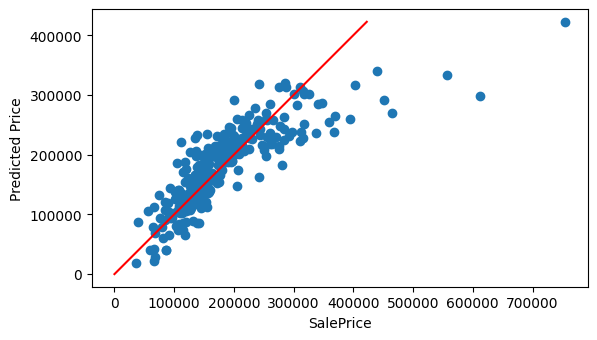

In [119]:
train_data_sq = train_data.copy()
val_data_sq = val_data.copy()
train_data_sq["GrLivArea_Sq"] = train_data["GrLivArea"] ** 2
val_data_sq["GrLivArea_Sq"] = val_data["GrLivArea"] ** 2

reg = LinearRegression()
reg.fit(train_data_sq, train_target)
predicted_prices = reg.predict(val_data_sq)

plot_predicted_prices(predicted_prices, val_target)

# Считаем лосс
train_loss, val_loss = calculate_loss(reg, train_data_sq, val_data_sq, train_target, val_target)
print(f"Среднеквадратичная ошибка: на train: {train_loss}, на val: {val_loss}")

## Дерево решений

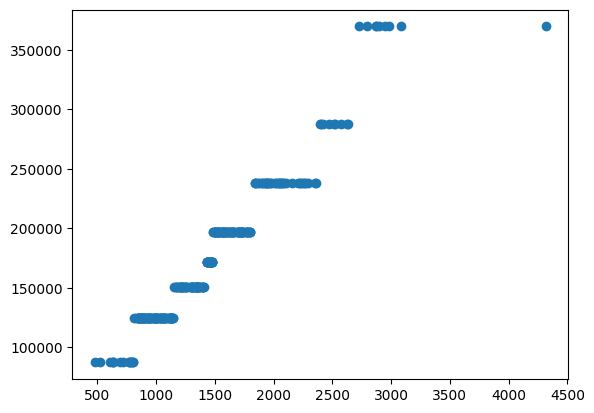

Среднеквадратичная ошибка: на train: 2889710788.137535, на val: 3704235103.5360603


In [114]:
from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor(max_depth=3)
reg.fit(train_data[["GrLivArea"]], train_target)
predicted_prices = reg.predict(val_data[["GrLivArea"]])

plt.scatter(val_data["GrLivArea"], predicted_prices)
plt.show()

# Считаем лосс
train_loss, val_loss = calculate_loss(reg, train_data[["GrLivArea"]], val_data[["GrLivArea"]], train_target, val_target)
print(f"Среднеквадратичная ошибка: на train: {train_loss}, на val: {val_loss}")

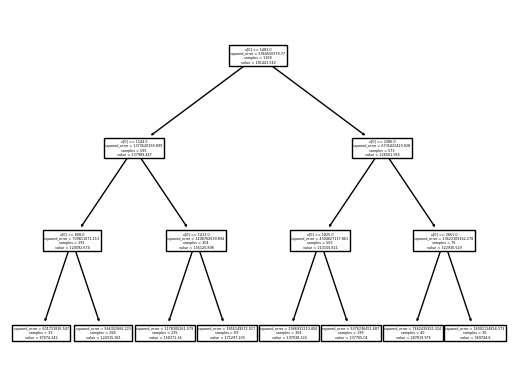

In [ ]:
plt.figure()
sklearn.tree.plot_tree(reg)
plt.savefig("tree.svg", format="svg")

Среднеквадратичная ошибка: на train: 2191757327.8444533, на val: 2806312761.649392


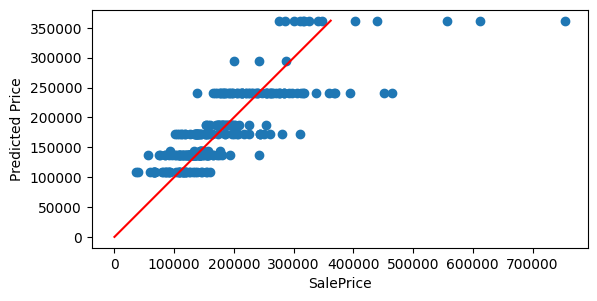

In [128]:
reg = DecisionTreeRegressor(max_depth=3)
reg.fit(train_data, train_target)
predicted_prices = reg.predict(val_data)

plot_predicted_prices(predicted_prices, val_target)

# Считаем лосс
train_loss, val_loss = calculate_loss(reg, train_data, val_data, train_target, val_target)
print(f"Среднеквадратичная ошибка: на train: {train_loss}, на val: {val_loss}")

Как глубина влияет на лосс?

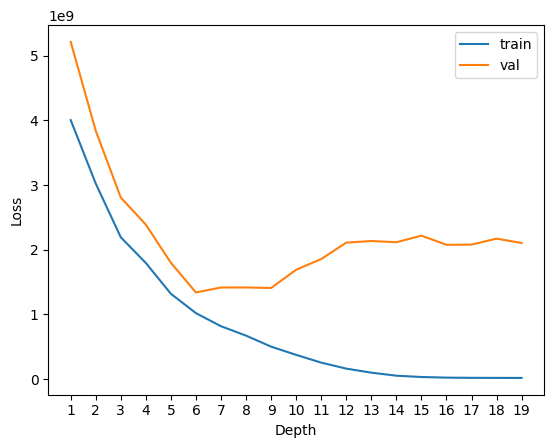

In [134]:
train_losses = []
val_losses = []
depths = range(1, 20)

for depth in depths:
    reg = DecisionTreeRegressor(max_depth=depth)
    reg.fit(train_data, train_target)
    predicted_prices = reg.predict(val_data)
    train_loss, val_loss = calculate_loss(reg, train_data, val_data, train_target, val_target)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

plt.plot(depths, train_losses, label="train")
plt.plot(depths, val_losses, label="val")
plt.xlabel("Depth")
plt.ylabel("Loss")
plt.xticks(depths)
plt.legend()
plt.show()


С увеличением глубины лосс на трейне уменьшается, в на валидации начианет расти - деревья с большой глубиной переобучаются.

In [141]:
U = np.array([[0, 1, 2], [1, 0, 1], [2, 1, 0]])
V = np.array([[0, 1, 1], [1, 0, 2], [1, 2, 0]])
T = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 1]])
print(V @ np.linalg.inv(U))
T.T @ U @ T

[[ 0.75 -0.5   0.25]
 [ 0.25  1.5  -0.25]
 [ 0.75 -1.5   1.25]]


array([[0, 1, 1],
       [1, 0, 2],
       [1, 2, 0]])